In [1]:
# Import packages and set configurations

import polars as pl
_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Function to get path

from pathlib import Path

def get_path(cell_line: str, path_file: str = "data_path.txt") -> str:
    """
    Reads a base directory path from a text file and returns the full path
    to the cell line data directory.

    Args:
        cell_line (str): The name of the cell line (e.g. "K562" or "HepG2").
        path_file (str): Path to the text file containing the base directory path.

    Returns:
        str: Full path to the data file for the given cell line.
    """
    # Read base path from file
    base_path = Path(path_file).read_text().strip()
    
    # Build full path
    full_path = Path(base_path) / f"{cell_line}_all-data.feather"
    
    return str(full_path)

In [3]:
# Getting paths

K562_PATH = get_path("K562")
K562 = pl.read_ipc(K562_PATH)

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


In [3]:
HEPG2_PATH = get_path("HepG2")
HEPG2 = pl.read_ipc(HEPG2_PATH)

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


# Counts vs local SHAP for RBFOX2 bound at pos 4 for K562

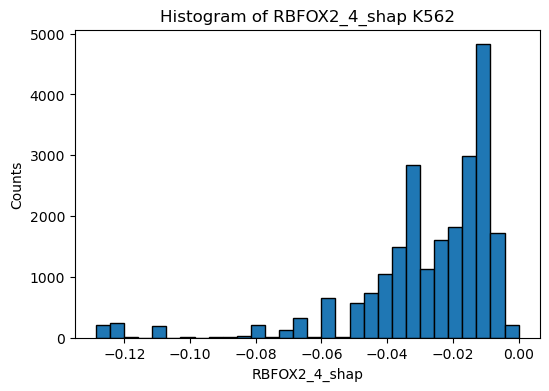

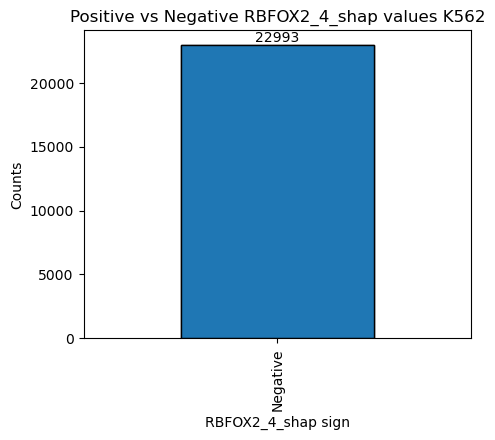

In [5]:
# Filter for K562, get rows where RBP_KD_Target = RBFOX2, has_RBP_KD_4 = true

filtered_K562 = (
    K562
    .filter(
        (pl.col("RBP_KD_Target") == "RBFOX2") & (pl.col("has_RBP_KD_4"))
    )
)

# Get rid of unneccessary columns 

columns_to_keep = [
    "RBP_KD_Target",
    "Sample Name",
    "FDR",
    "Raw P-Val",
    "RBFOX2_4_shap",
    "RBFOX2_4_binding"
]

filtered_K562 = filtered_K562.select(columns_to_keep)

# Make another dataframe that has all rows where RBFOX2 is bound at pos 4 including the in-silico KDs

rbfox2_bound_4_K562 = (
    K562
    .filter(
        (pl.col("RBFOX2_4_binding") == 1)
        | (
            (pl.col("has_RBP_KD_4"))
            & (pl.col("RBP_KD_Target") == "RBFOX2")
        )
    )
)

rbfox2_bound_4_K562 = rbfox2_bound_4_K562.select(columns_to_keep)

# convert to pandas
df_pd = rbfox2_bound_4_K562.to_pandas()

# Confirm that shap at pos 4 is never positive

df_sorted = df_pd.sort_values(by="RBFOX2_4_shap", ascending=False)

# make histogram
plt.figure(figsize=(6,4))
plt.hist(df_pd["RBFOX2_4_shap"], bins=30, edgecolor="black")
plt.xlabel("RBFOX2_4_shap")
plt.ylabel("Counts")
plt.title("Histogram of RBFOX2_4_shap K562")
plt.show()

df_pd["shap_sign"] = df_pd["RBFOX2_4_shap"].apply(lambda x: "Positive" if x > 0 else "Negative")

# count how many in each category
counts = df_pd["shap_sign"].value_counts()

# plot
plt.figure(figsize=(5,4))
counts.plot(kind="bar", edgecolor="black")
ax = counts.plot(kind="bar", edgecolor="black")
plt.xlabel("RBFOX2_4_shap sign")
plt.ylabel("Counts")
plt.title("Positive vs Negative RBFOX2_4_shap values K562")
for i, count in enumerate(counts):
    ax.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)
plt.show()

# Counts vs local SHAP for RBFOX2 bound at pos 4 for HepG2

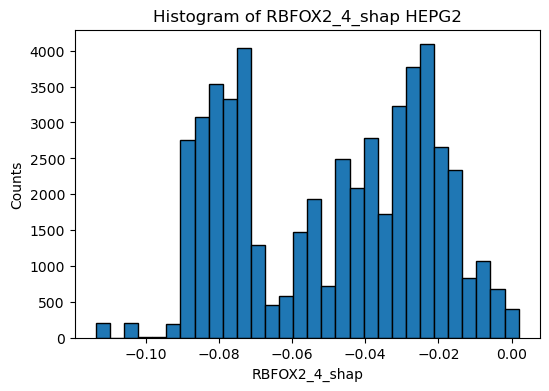

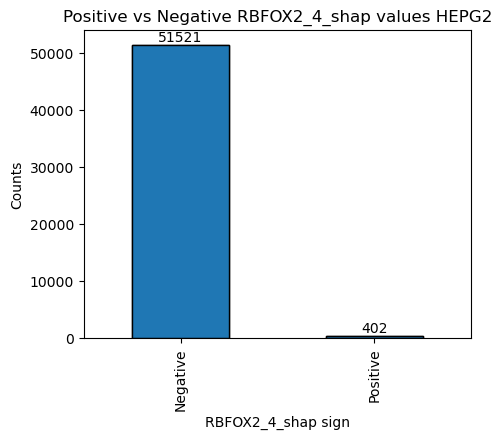

In [5]:
# Filter for HEPG2, get rows where RBP_KD_Target = RBFOX2, has_RBP_KD_4 = true

filtered_HEPG2 = (
    HEPG2
    .filter(
        (pl.col("RBP_KD_Target") == "RBFOX2") & (pl.col("has_RBP_KD_4"))
    )
)

# Get rid of unneccessary columns 

columns_to_keep = [
    "RBP_KD_Target",
    "Sample Name",
    "FDR",
    "Raw P-Val",
    "RBFOX2_4_shap",
    "RBFOX2_4_binding"
]

filtered_HEPG2 = filtered_HEPG2.select(columns_to_keep)

rbfox2_bound_4_HEPG2 = (
    HEPG2
    .filter(
        (pl.col("RBFOX2_4_binding") == 1)
        | (
            (pl.col("has_RBP_KD_4"))
            & (pl.col("RBP_KD_Target") == "RBFOX2")
        )
    )
)

rbfox2_bound_4_HEPG2 = rbfox2_bound_4_HEPG2.select(columns_to_keep)

df2_pd = rbfox2_bound_4_HEPG2.to_pandas()

# Checking shap manually

df2_sorted = df2_pd.sort_values(by="RBFOX2_4_shap", ascending=False)

# make histogram
plt.figure(figsize=(6,4))
plt.hist(df2_pd["RBFOX2_4_shap"], bins=30, edgecolor="black")
plt.xlabel("RBFOX2_4_shap")
plt.ylabel("Counts")
plt.title("Histogram of RBFOX2_4_shap HEPG2")
plt.show()

df2_pd["shap_sign"] = df2_pd["RBFOX2_4_shap"].apply(lambda x: "Positive" if x > 0 else "Negative")

# count how many in each category
counts = df2_pd["shap_sign"].value_counts()

# plot
plt.figure(figsize=(5,4))
counts.plot(kind="bar", edgecolor="black")
ax = counts.plot(kind="bar", edgecolor="black")
plt.xlabel("RBFOX2_4_shap sign")
plt.ylabel("Counts")
plt.title("Positive vs Negative RBFOX2_4_shap values HEPG2")
for i, count in enumerate(counts):
    ax.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)
plt.show()